
# EDA: Tanase (2009) Diameter-Correction Exponent Grid (`tanase2009_diameter_correction_exponent_grid.csv`)

Unlike the other summary tables, this file is a **complete lookup grid**: 2
pressure bins x 3 mass-flux bins x 4 quality bins = 24 rows, each carrying a
single empirical diameter-correction exponent `exponent_n` (used to correct
CHF Look-Up Table predictions between reference and non-reference tube
diameters). EDA here visualizes it as the grid it is, rather than as
per-source ranges.

## 1. Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/tanase2009_diameter_correction_exponent_grid")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / "tanase2009_diameter_correction_exponent_grid.csv")
df

,Pressure_kPa_range,MassFlux_kg_m2s_range,Quality_range,exponent_n
0,100-14000,0-250,-0.5 to -0.25,-0.2
1,100-14000,0-250,-0.25 to 0,-0.2
2,100-14000,0-250,0 to 0.5,-0.2
3,100-14000,0-250,0.5 to 1,-0.3
4,100-14000,250-3000,-0.5 to -0.25,0.4
5,100-14000,250-3000,-0.25 to 0,0.4
6,100-14000,250-3000,0 to 0.5,0.5
7,100-14000,250-3000,0.5 to 1,0.6
8,100-14000,3000-8000,-0.5 to -0.25,0.3
9,100-14000,3000-8000,-0.25 to 0,0.3


## 2. Grid Structure Check

In [2]:
print("Unique Pressure_kPa_range bins:", df["Pressure_kPa_range"].unique())
print("Unique MassFlux_kg_m2s_range bins:", df["MassFlux_kg_m2s_range"].unique())
print("Unique Quality_range bins:", df["Quality_range"].unique())
print("Rows:", len(df), " = ", df["Pressure_kPa_range"].nunique(),
      "x", df["MassFlux_kg_m2s_range"].nunique(),
      "x", df["Quality_range"].nunique())
print("Any missing exponent_n:", df["exponent_n"].isna().any())

Unique Pressure_kPa_range bins: ['100-14000' '14000-21000']
Unique MassFlux_kg_m2s_range bins: ['0-250' '250-3000' '3000-8000']
Unique Quality_range bins: ['-0.5 to -0.25' '-0.25 to 0' '0 to 0.5' '0.5 to 1']
Rows: 24  =  2 x 3 x 4
Any missing exponent_n: False


## 3. Exponent Heatmap (Quality x Mass Flux, faceted by Pressure)

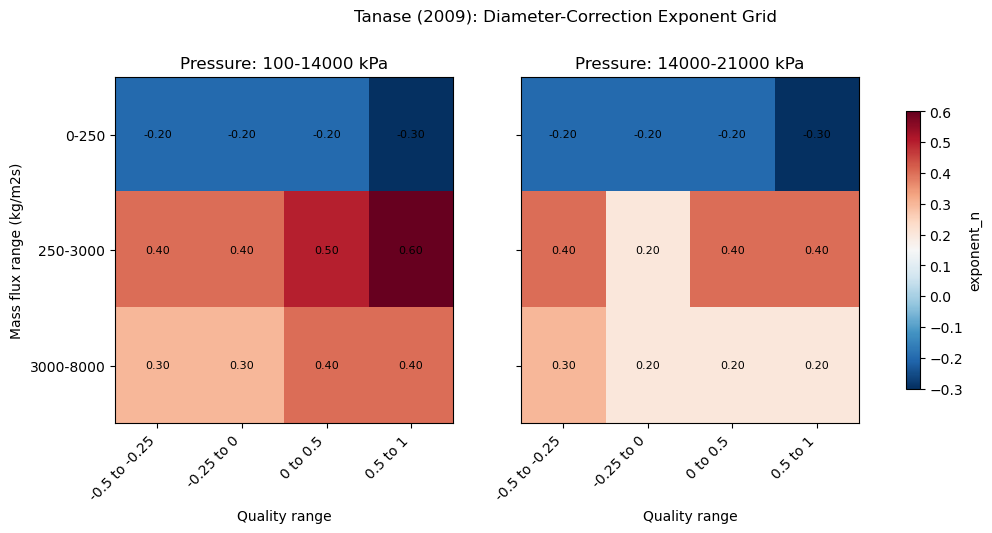

In [3]:
pressure_bins = df["Pressure_kPa_range"].unique()
quality_order = df["Quality_range"].unique()
massflux_order = df["MassFlux_kg_m2s_range"].unique()

fig, axes = plt.subplots(1, len(pressure_bins), figsize=(6 * len(pressure_bins), 4.5),
                          squeeze=False, sharey=True)
axes = axes[0]
vmin, vmax = df["exponent_n"].min(), df["exponent_n"].max()
for i, (ax, pbin) in enumerate(zip(axes, pressure_bins)):
    sub = df[df["Pressure_kPa_range"] == pbin]
    grid = sub.pivot(index="MassFlux_kg_m2s_range", columns="Quality_range", values="exponent_n")
    grid = grid.reindex(index=massflux_order, columns=quality_order)
    im = ax.imshow(grid.values, cmap="RdBu_r", vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(len(quality_order)))
    ax.set_xticklabels(quality_order, rotation=45, ha="right")
    ax.set_yticks(range(len(massflux_order)))
    ax.set_yticklabels(massflux_order)
    ax.set_xlabel("Quality range")
    if i == 0:
        ax.set_ylabel("Mass flux range (kg/m2s)")
    ax.set_title(f"Pressure: {pbin} kPa")
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            ax.text(j, i, f"{grid.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes, shrink=0.8, label="exponent_n")
fig.suptitle("Tanase (2009): Diameter-Correction Exponent Grid", y=1.03)
fig.savefig(FIG_DIR / "exponent_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Takeaways

- The grid is complete (no missing `exponent_n` cells) and exactly
  2 x 3 x 4 = 24 rows, confirming this is a lookup table rather than sampled
  data — no missing-value or outlier analysis is meaningful here.
- `exponent_n` swings from negative (CHF decreases with diameter) at low
  mass flux to positive (CHF increases with diameter) at higher mass flux —
  the heatmap makes the sign flip pattern across mass-flux bins visible at a
  glance; pressure bin has comparatively little effect.
- Downstream use: given a target tube diameter and known (P, G, x) operating
  point, look up the matching cell's `exponent_n` to correct a reference-tube
  CHF prediction to the target diameter.
